In [14]:
from sklearn.tree import DecisionTreeClassifier
model_decisionTree = DecisionTreeClassifier(class_weight={0: 1, 1:3},
            criterion='gini',
            max_depth=8,
)

In [15]:
import ehr_utils
file_path_mean = 'data_cleaned/ver-noelectrolyte-logtransform_mean.csv'
X_train, X_test, Y_train, Y_test = ehr_utils.get_train_test(file_path_mean)
model_decisionTree.fit(X_train, Y_train)

DecisionTreeClassifier(class_weight={0: 1, 1: 3}, max_depth=8)

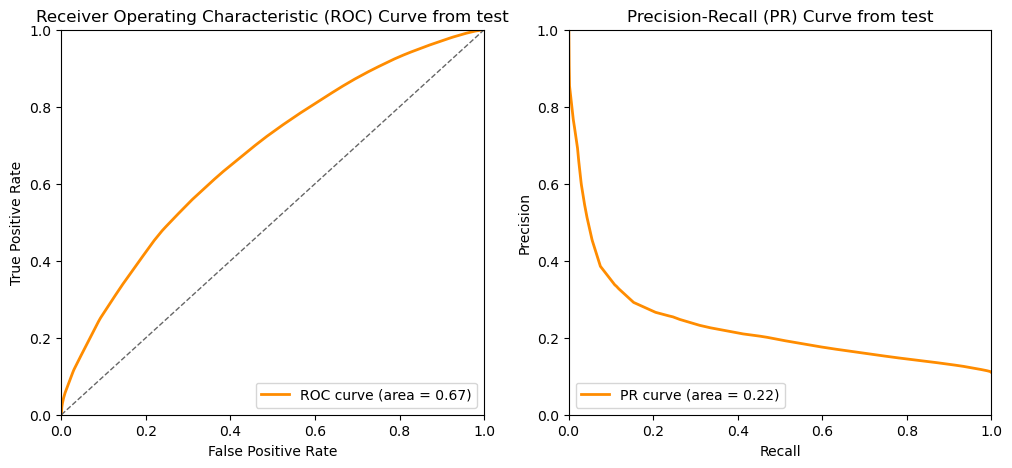

AUROC: 0.6741
AUPRC: 0.2214


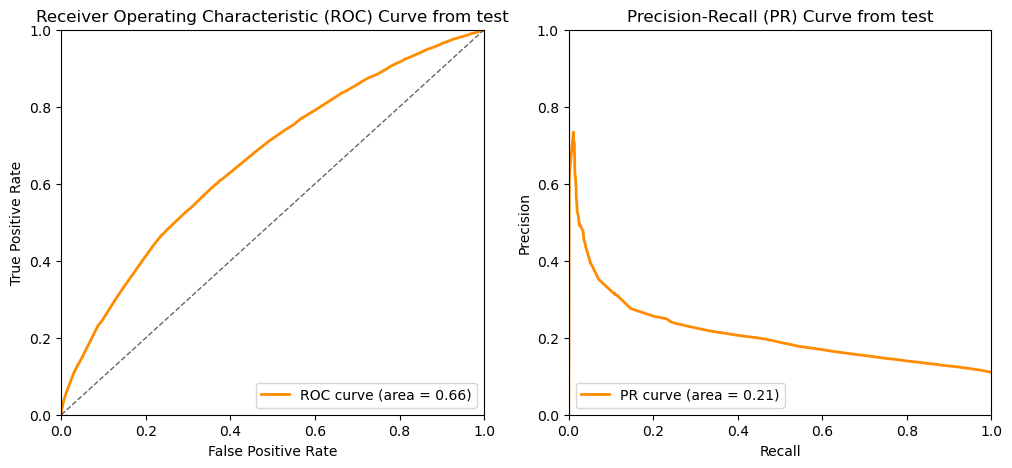

AUROC: 0.6608
AUPRC: 0.2080
[0.6608057918451131, 0.6545233113612386, 0.6686645031898142, 0.875333120136446, 0.10771349862258953, 0.9707483692023217, 0.31399317406143346, 0.8974618726900034, 0.1604020306650941]


In [16]:
import ehr_utils

model_decisionTree.score(X_test, Y_test)

Y_prob, Y_pred = ehr_utils.get_prediction_results(model_decisionTree, X_test)
Y_train_prob, Y_train_pred = ehr_utils.get_prediction_results(model_decisionTree, X_train)
ehr_utils.plot_roc_pr_curves(Y_train, Y_train_prob, 'dt', 'test')
ehr_utils.plot_roc_pr_curves(Y_test, Y_prob, 'dt', 'test')
print(ehr_utils.eval_model(Y_test, Y_prob, Y_pred))